# Final Project

In [6]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

## Exploratory Data Analysis

In [7]:
life_expectancy_df = pd.read_csv('life_expectancy.csv')
life_expectancy_df.head(20)

,Country,Year,Status,Population,Hepatitis B,Measles,Polio,Diphtheria,HIV/AIDS,infant deaths,under-five deaths,Total expenditure,GDP,BMI,thinness 1-19 years,Alcohol,Schooling,Life expectancy
0,Afghanistan,2015,Developing,33736494.0,65.0,1154,6.0,65.0,0.1,62,83,8.16,584.259210,19.1,17.2,0.01,10.1,65.0
1,Afghanistan,2014,Developing,327582.0,62.0,492,58.0,62.0,0.1,64,86,8.18,612.696514,18.6,17.5,0.01,10.0,59.9
2,Afghanistan,2013,Developing,31731688.0,64.0,430,62.0,64.0,0.1,66,89,8.13,631.744976,18.1,17.7,0.01,9.9,59.9
3,Afghanistan,2012,Developing,3696958.0,67.0,2787,67.0,67.0,0.1,69,93,8.52,669.959000,17.6,17.9,0.01,9.8,59.5
4,Afghanistan,2011,Developing,2978599.0,68.0,3013,68.0,68.0,0.1,71,97,7.87,63.537231,17.2,18.2,0.01,9.5,59.2
5,Afghanistan,2010,Developing,2883167.0,66.0,1989,66.0,66.0,0.1,74,102,9.20,553.328940,16.7,18.4,0.01,9.2,58.8
6,Afghanistan,2009,Developing,284331.0,63.0,2861,63.0,63.0,0.1,77,106,9.42,445.893298,16.2,18.6,0.01,8.9,58.6
7,Afghanistan,2008,Developing,2729431.0,64.0,1599,64.0,64.0,0.1,80,110,8.33,373.361116,15.7,18.8,0.03,8.7,58.1
8,Afghanistan,2007,Developing,26616792.0,63.0,1141,63.0,63.0,0.1,82,113,6.73,369.835796,15.2,19.0,0.02,8.4,57.5
9,Afghanistan,2006,Developing,2589345.0,64.0,1990,58.0,58.0,0.1,84,116,7.43,272.563770,14.7,19.2,0.03,8.1,57.3


In [8]:
diseases_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'infant deaths', 'Alcohol', 'Schooling', 'GDP', 'BMI', 'Total expenditure', 'thinness  1-19 years'])

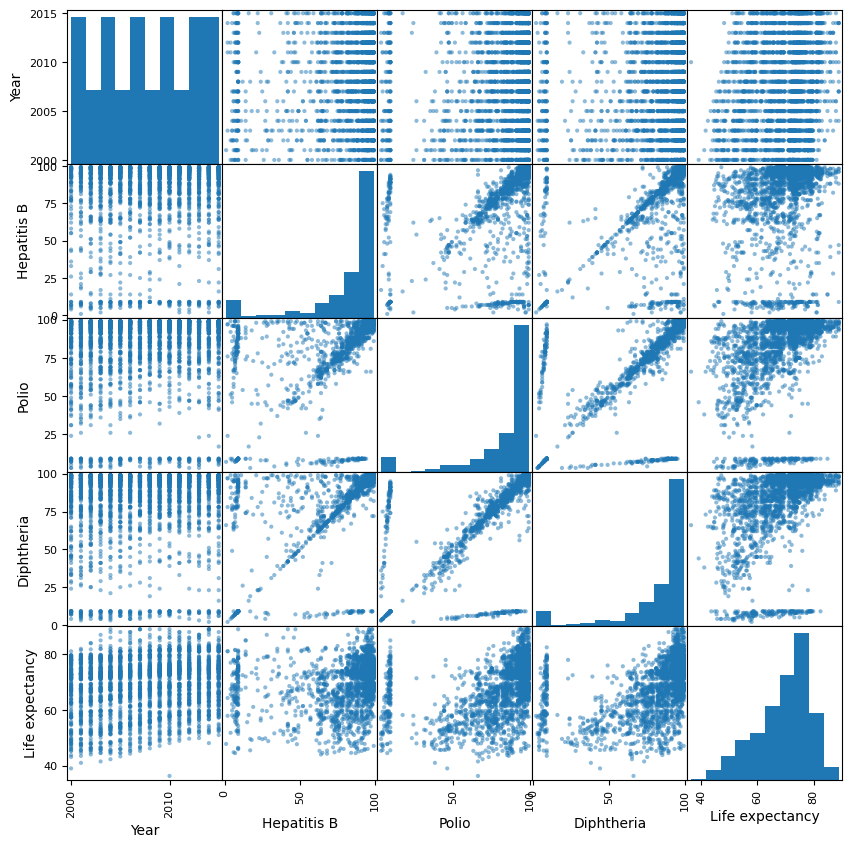

In [9]:
g = pd.plotting.scatter_matrix(diseases_df, figsize=(10,10))
plt.show()

In [10]:
young_deaths_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'Polio', 'Population', 'HIV/AIDS', 'Diphtheria','Hepatitis B' , 'Alcohol', 'Schooling', 'GDP', 'BMI', 'Total expenditure', 'thinness  1-19 years'])

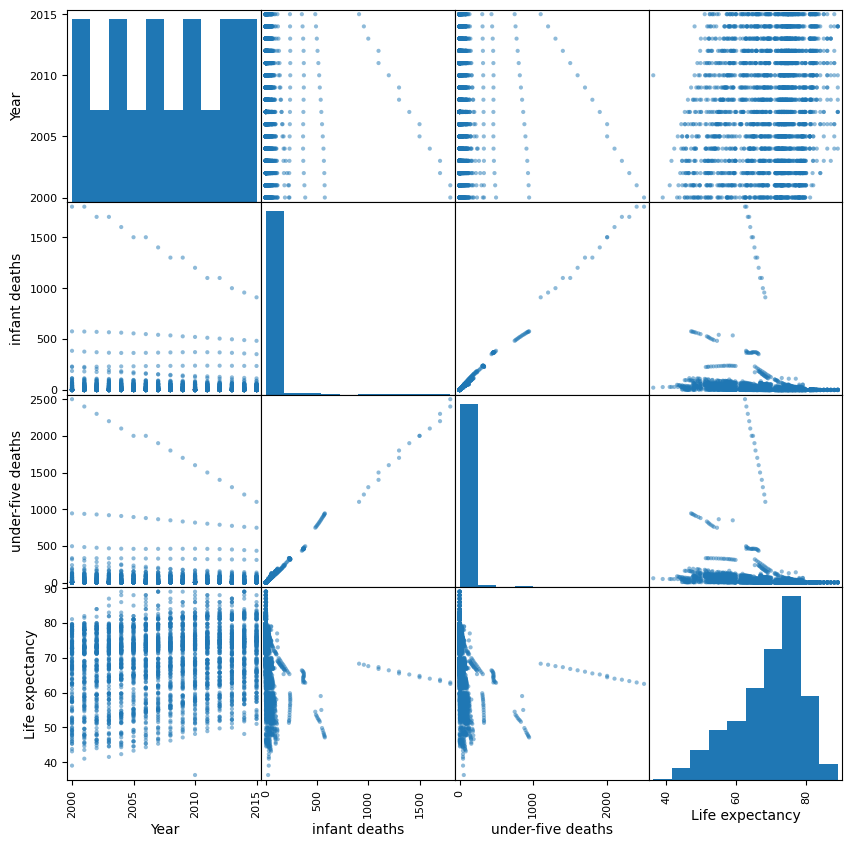

In [11]:
g = pd.plotting.scatter_matrix(young_deaths_df, figsize=(10,10))
plt.show()

In [12]:
GDP_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'infant deaths', 'Alcohol', 'Schooling', 'Hepatitis B','Polio','Diphtheria', 'BMI', 'Total expenditure', 'thinness  1-19 years'])

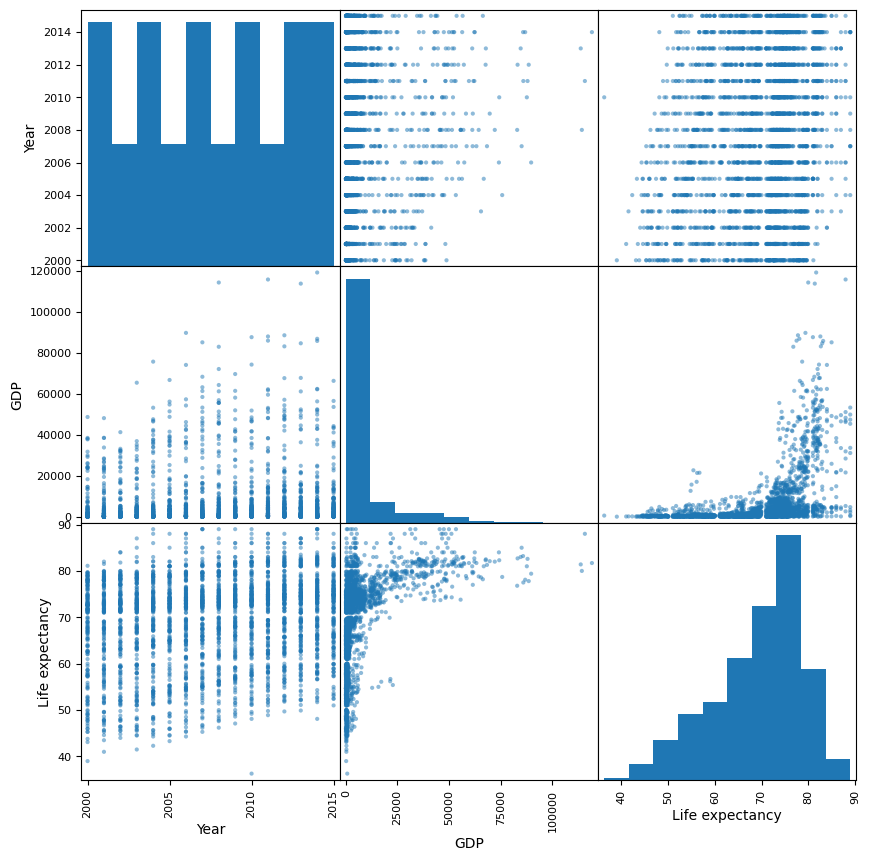

In [13]:
g = pd.plotting.scatter_matrix(GDP_df, figsize=(10,10))
plt.show()

In [14]:
BMI_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'infant deaths', 'Alcohol', 'Schooling', 'GDP', 'Polio','Diphtheria','Hepatitis B', 'Total expenditure', 'thinness  1-19 years'])

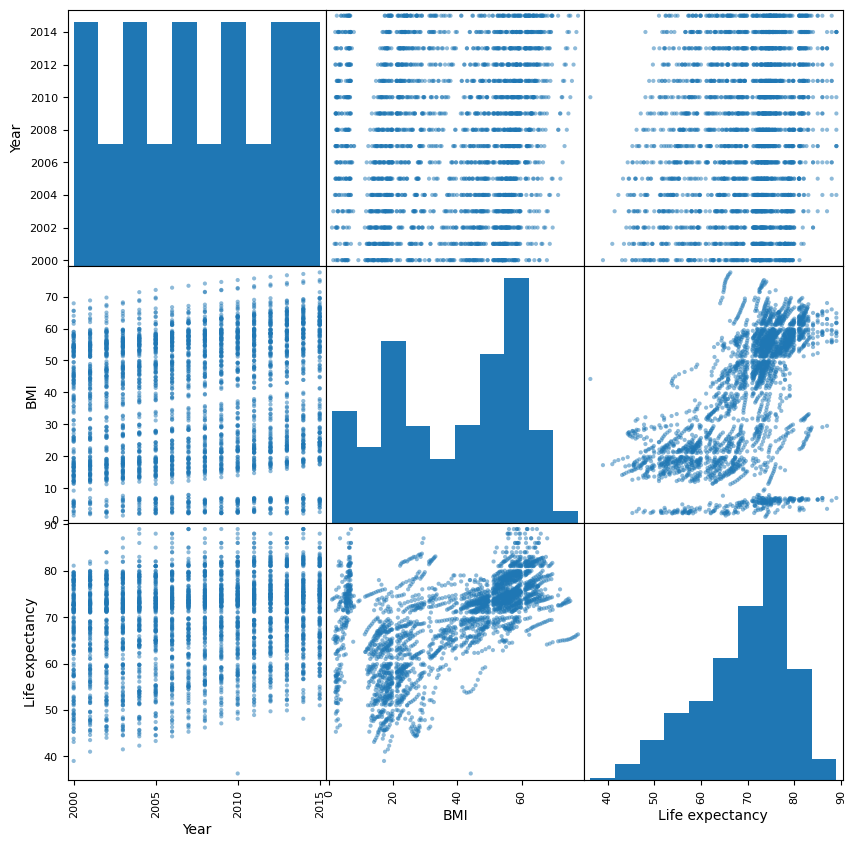

In [15]:
g = pd.plotting.scatter_matrix(BMI_df, figsize=(10,10))
plt.show()

In [16]:
alcohol_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'BMI','infant deaths', 'Schooling', 'GDP', 'Polio','Diphtheria','Hepatitis B', 'Total expenditure', 'thinness  1-19 years'])

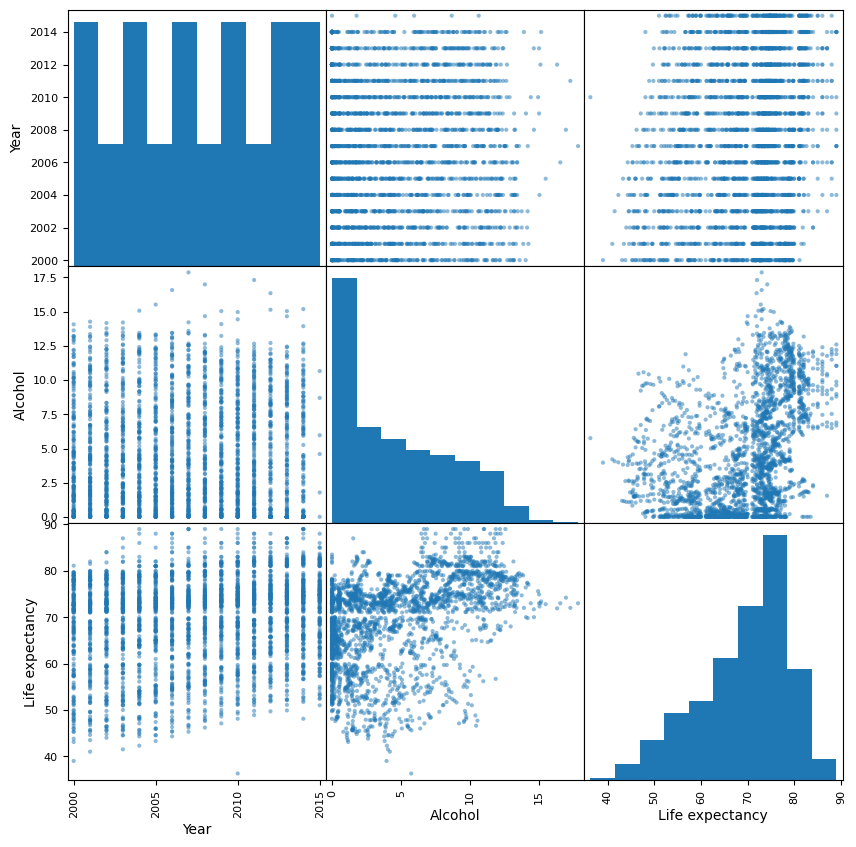

In [17]:
g = pd.plotting.scatter_matrix(alcohol_df, figsize=(10,10))
plt.show()

In [18]:
total_expendicture_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'Alcohol', 'BMI','infant deaths', 'Schooling', 'GDP', 'Polio','Diphtheria','Hepatitis B', 'HIV/AIDS', 'thinness  1-19 years'])

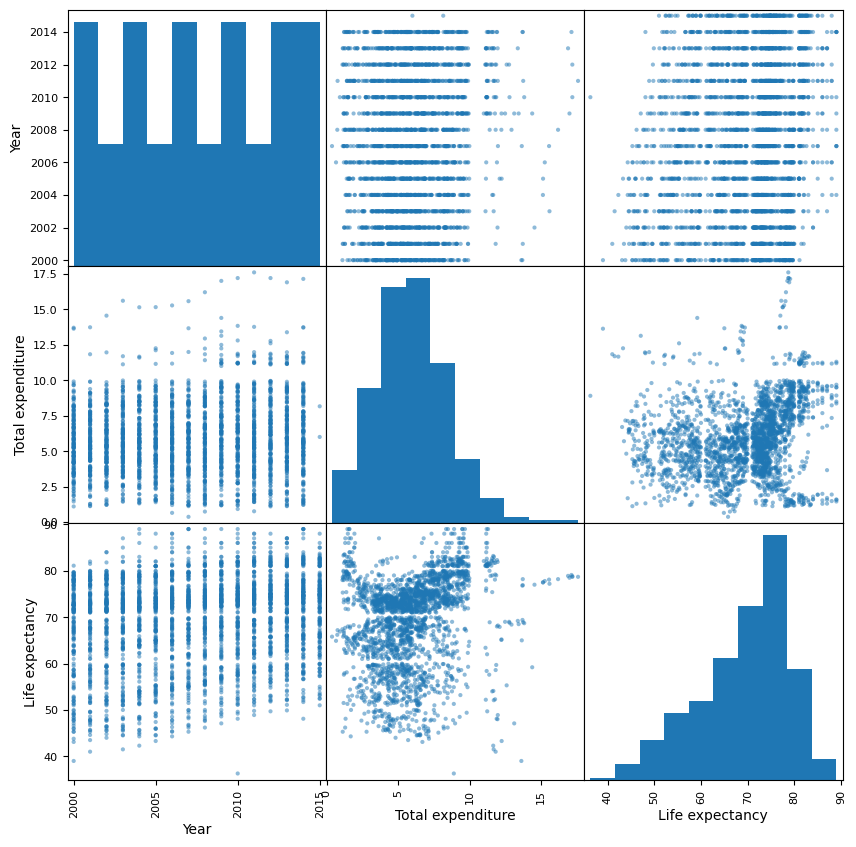

In [19]:
g = pd.plotting.scatter_matrix(total_expendicture_df, figsize=(10,10))
plt.show()

In [20]:
schooling_df = life_expectancy_df.drop(columns=['Status', 'Total expenditure', 'under-five deaths', 'Population', 'Alcohol', 'BMI','infant deaths', 'Measles', 'GDP', 'Polio','Diphtheria','Hepatitis B', 'HIV/AIDS', 'thinness  1-19 years'])

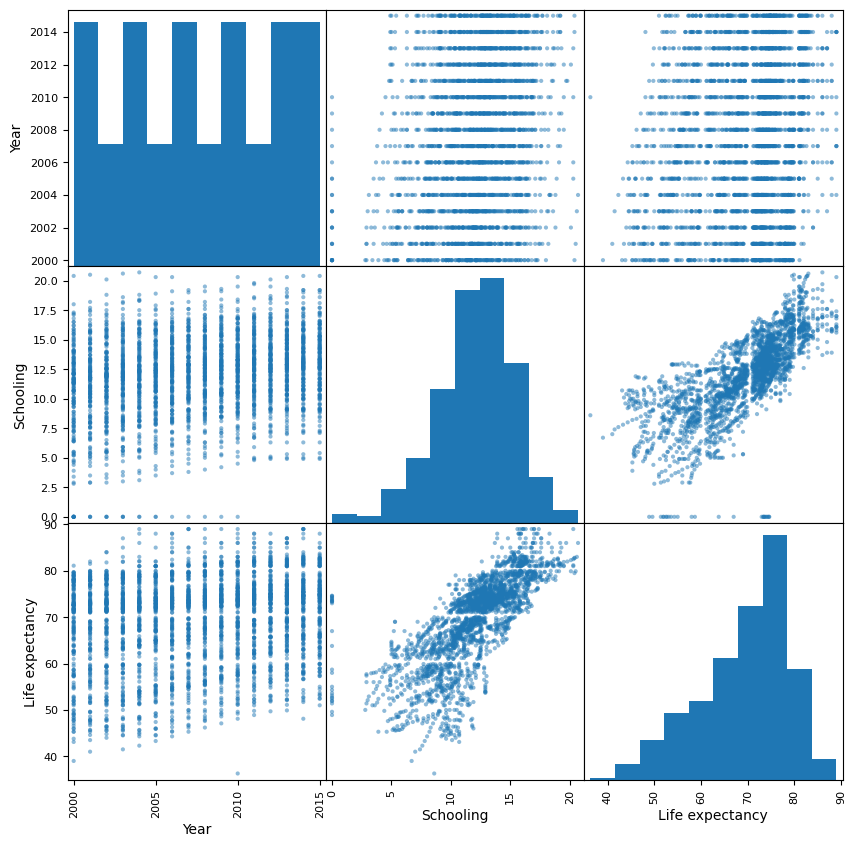

In [21]:
g = pd.plotting.scatter_matrix(schooling_df, figsize=(10,10))
plt.show()

In [22]:
correlation_df = life_expectancy_df.drop(columns=['Status', 'Country'])

In [23]:
correlation_df.corr()

,Year,Population,Hepatitis B,Measles,Polio,Diphtheria,HIV/AIDS,infant deaths,under-five deaths,Total expenditure,GDP,BMI,thinness 1-19 years,Alcohol,Schooling,Life expectancy
Year,1.000000,0.016996,0.100585,-0.083160,0.094647,0.128703,-0.137193,-0.031105,-0.036478,0.087076,0.102521,0.106649,-0.039319,-0.049223,0.208911,0.169144
Population,0.016996,1.000000,-0.124750,0.323543,-0.032998,-0.024220,-0.029245,0.568906,0.553922,-0.078426,-0.028052,-0.070635,0.254817,-0.032587,-0.028594,-0.019353
Hepatitis B,0.100585,-0.124750,1.000000,-0.147957,0.484224,0.610164,-0.115024,-0.224604,-0.233360,0.069698,0.082088,0.155585,-0.127751,0.077390,0.214297,0.256613
Measles,-0.083160,0.323543,-0.147957,1.000000,-0.169115,-0.174630,0.045853,0.493982,0.512826,-0.104606,-0.073078,-0.174793,0.258161,-0.051190,-0.151299,-0.198178
Polio,0.094647,-0.032998,0.484224,-0.169115,1.000000,0.672972,-0.159482,-0.172132,-0.188249,0.143162,0.210771,0.287940,-0.226663,0.213613,0.410212,0.464366
Diphtheria,0.128703,-0.024220,0.610164,-0.174630,0.672972,1.000000,-0.162677,-0.173307,-0.191175,0.156599,0.199547,0.284376,-0.225360,0.214813,0.414368,0.476795
HIV/AIDS,-0.137193,-0.029245,-0.115024,0.045853,-0.159482,-0.162677,1.000000,0.027153,0.039157,-0.000319,-0.137283,-0.244487,0.200556,-0.049072,-0.220601,-0.559105
infant deaths,-0.031105,0.568906,-0.224604,0.493982,-0.172132,-0.173307,0.027153,1.000000,0.996948,-0.122950,-0.102310,-0.214691,0.471186,-0.110582,-0.186106,-0.201055
under-five deaths,-0.036478,0.553922,-0.233360,0.512826,-0.188249,-0.191175,0.039157,0.996948,1.000000,-0.124488,-0.105913,-0.224972,0.470691,-0.106273,-0.200276,-0.224903
Total expenditure,0.087076,-0.078426,0.069698,-0.104606,0.143162,0.156599,-0.000319,-0.122950,-0.124488,1.000000,0.141139,0.241852,-0.279021,0.304126,0.266692,0.222788


**From the exploratory data anyalysis, schooling seemed to have the highest correlation with life expectancy. This is the average number of years people in a country typically study in school.<br>
I will be looking at how schooling affects life expectancy.**

## Problem 1: Setup

### 1.1 Dataset selection

Picked from existing Google sheets list: Countries Life Expectancy (Kaggle)<br>
Problem to solve: Does the average amount of schooling for a country impact the life expectancy?

### 1.2 Github setup

Accepted and cloned

## Problem 2: Improvements

Some recommendations that were given during the meeting:

- Check for correlation between different columns and life expectancy. Try to pick one with high correlation.
- Plot line graph graph of different countries' life expectancy throughout the years and see how some countries' life expectancies compare.
- Line graph would work better for average life expectancy each year as well.
- Linear regression does not appear to be the best model to train for the scatter plots of immunization percentages of different diseases. Research for a model that would be a better fit.

Based on these recommendations, I looked at the graphs and value of the correlation bewtween life expectancy and the differnt columns and I found that schooling has the highest correlation with life expectancy. So I decided to look at how the number of years in school imacted life expectancy instead of vaccination percentages of the three diseases.<br>
Everyhting else was kept pretty much the same as there were no major recommendations for how the rest of the project was done. I changed the bar chart to a line graph when showing how life expectancy changed throughout the years and plotted some more bar charts showing how schooling changed through the years. Based on the suggestions I also plotted some different countries life expectancies through the years to show how each country might compare to others. <br>
As for the model I chose to use, I found that Linear Regression was a better fit now that I'm looking at schooling and life expectancy so I decided to use Linear Regression as my model to train.<br>
I also thought it would have been interesting to look at the schooling and life expectancy for the year 2000 and compare it to the schooling and life expectancy for the year 2015 (the earliest and latest years of data).

## Problem 3: Data Collection

### 3.1 Dataset description

The dataset I chose was Countries Life Expectancy, found on Kaggle. This dataset takes information like population, major diseases, infant deaths, alcohol and more to uncover reasons why countries have different life expectancies. The purpose of the dataset is to understand the link between healthcare, socioeconomic factors, and life expectancy in different countries. The country’s development status and population are taken into account when looking at factors that can affect the life expectancy of a country. The percentages of people who are immunized against diseases like Hepatitis B, Polio and Measles are also reported. The number of deaths by HIV/AIDS, infant deaths and under 5-years deaths are also taken into consideration. Things like GDP, BMI and Liters of alcohol consumed are also looked at. These things might impact the overall health and wellbeing of a country’s population and could pose a factor in a country’s life expectancy age. The number of years that people go to school in each country is also looked at and the ratio of government medical-health expenses to total government expenses is given as a percentage. The data is collected and shown from the year 2001 to 2015 for each country, so we can see if the life expectancy goes up or down in that time frame. 

### 3.2 Dataset download

Already downloaded

In [24]:
schooling_df = life_expectancy_df.drop(columns=['Hepatitis B','Diphtheria','Polio','Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'infant deaths', 'Alcohol', 'GDP', 'BMI', 'Total expenditure', 'thinness  1-19 years'])

In [25]:
# The columns I will be looking at

schooling_df

,Country,Year,Schooling,Life expectancy
0,Afghanistan,2015,10.1,65.0
1,Afghanistan,2014,10.0,59.9
2,Afghanistan,2013,9.9,59.9
3,Afghanistan,2012,9.8,59.5
4,Afghanistan,2011,9.5,59.2
...,...,...,...,...
2843,Zimbabwe,2004,9.2,44.3
2844,Zimbabwe,2003,9.5,44.5
2845,Zimbabwe,2002,10.0,44.8
2846,Zimbabwe,2001,9.8,45.3


## Problem 4: Data Preprocessing

### 4.1 Data cleaning

In [26]:
# (1) Data exploration

In [27]:
schooling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          2848 non-null   object 
 1   Year             2848 non-null   int64  
 2   Schooling        2688 non-null   float64
 3   Life expectancy  2848 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 89.1+ KB


In [28]:
schooling_df.sample(50)

,Country,Year,Schooling,Life expectancy
223,Barbados,2000,14.0,73.3
2483,Thailand,2012,13.7,74.3
99,Armenia,2012,12.7,74.4
835,Estonia,2012,16.5,76.3
754,Ecuador,2013,13.4,76.0
27,Albania,2004,10.9,73.0
2344,Spain,2007,16.0,89.0
9,Afghanistan,2006,8.1,57.3
307,Bolivia (Plurinational State of),2012,13.8,69.8
1365,Kyrgyzstan,2010,12.2,68.8


In [29]:
# (2) Looking for missing values

In [30]:
schooling_df.isnull().sum()

Country              0
Year                 0
Schooling          160
Life expectancy      0
dtype: int64

In [31]:
# Looks like there are some null values in the Schooling column

In [32]:
# (3) Handeling the NaN

# Replace with the average of Schooling

In [33]:
schooling_df['Schooling'].fillna(round(schooling_df['Schooling'].mean(skipna=True), 1), inplace=True)

In [34]:
schooling_df.sample(20)

,Country,Year,Schooling,Life expectancy
1384,Lao People's Democratic Republic,2007,9.0,62.1
1501,Madagascar,2002,8.3,59.3
369,Brunei Darussalam,2014,15.0,77.6
2301,Somalia,2002,12.1,58.0
2089,Saint Lucia,2006,12.4,73.5
1460,Lithuania,2011,16.7,72.8
1854,Norway,2001,17.5,78.8
1865,Oman,2006,11.6,74.7
1443,Libya,2012,13.7,72.9
687,Democratic People's Republic of Korea,2000,12.1,65.4


In [35]:
schooling_df.isnull().sum()

Country            0
Year               0
Schooling          0
Life expectancy    0
dtype: int64

In [36]:
# Making 2015 and 2000 schooling dataframes

schooling_2015_df = schooling_df[schooling_df['Year'] == 2015]
schooling_2000_df = schooling_df[schooling_df['Year'] == 2000]

In [37]:
schooling_2015_df

,Country,Year,Schooling,Life expectancy
0,Afghanistan,2015,10.1,65.0
16,Albania,2015,14.2,77.8
32,Algeria,2015,14.4,75.6
48,Angola,2015,11.4,52.4
64,Antigua and Barbuda,2015,13.9,76.4
...,...,...,...,...
2768,Venezuela (Bolivarian Republic of),2015,14.3,74.1
2784,Viet Nam,2015,12.6,76.0
2800,Yemen,2015,9.0,65.7
2816,Zambia,2015,12.5,61.8


In [38]:
schooling_2000_df

,Country,Year,Schooling,Life expectancy
15,Afghanistan,2000,5.5,54.8
31,Albania,2000,10.7,72.6
47,Algeria,2000,10.7,71.3
63,Angola,2000,4.6,45.3
79,Antigua and Barbuda,2000,0.0,73.6
...,...,...,...,...
2783,Venezuela (Bolivarian Republic of),2000,10.6,72.5
2799,Viet Nam,2000,10.4,73.4
2815,Yemen,2000,7.7,68.0
2831,Zambia,2000,9.6,43.8


In [39]:
# (4) Explain choosen method of dealing with missing data

**I chose to replace the NaN values with the average of the Schooling coulumn because there weren't any NaN values in the Life expectancy column and I wanted to utilize all of the life expectancies so I didn't just want to drop the columns with NaN in the Schooling. I felt it was best to handlethe NaN values this way becasue I still wanted to use the life expectancy data.**

### 4.2 Outlier detection

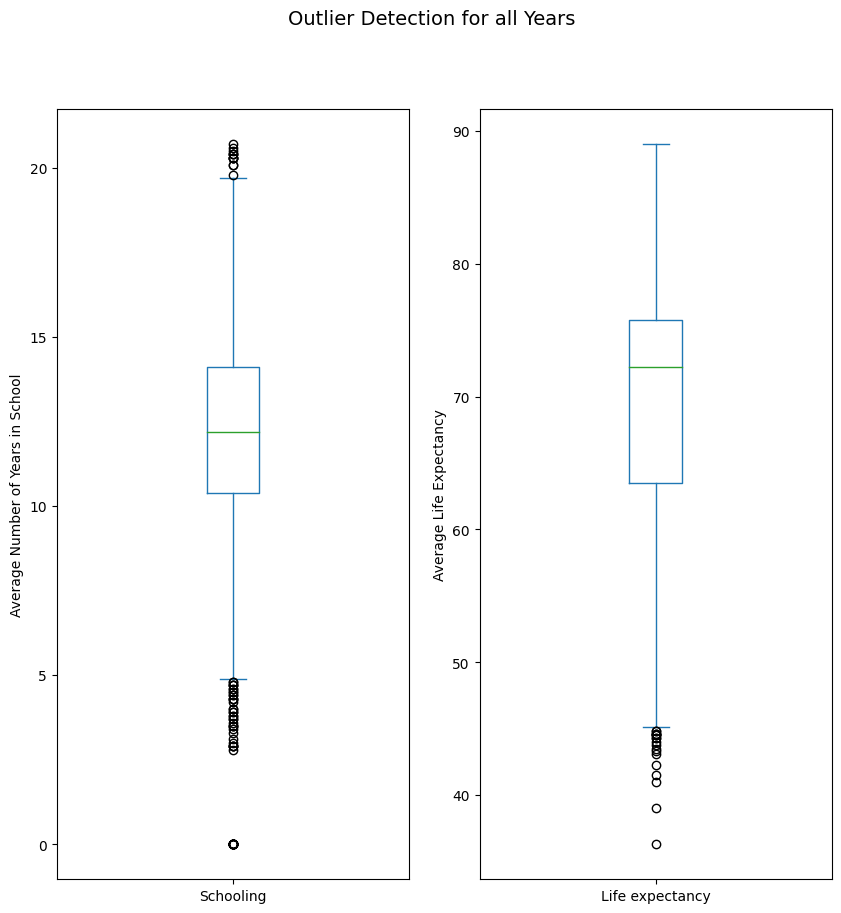

In [40]:
# All years

fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Outlier Detection for all Years", fontsize=14)
schooling_df['Schooling'].plot.box(ax=axis[0])
schooling_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

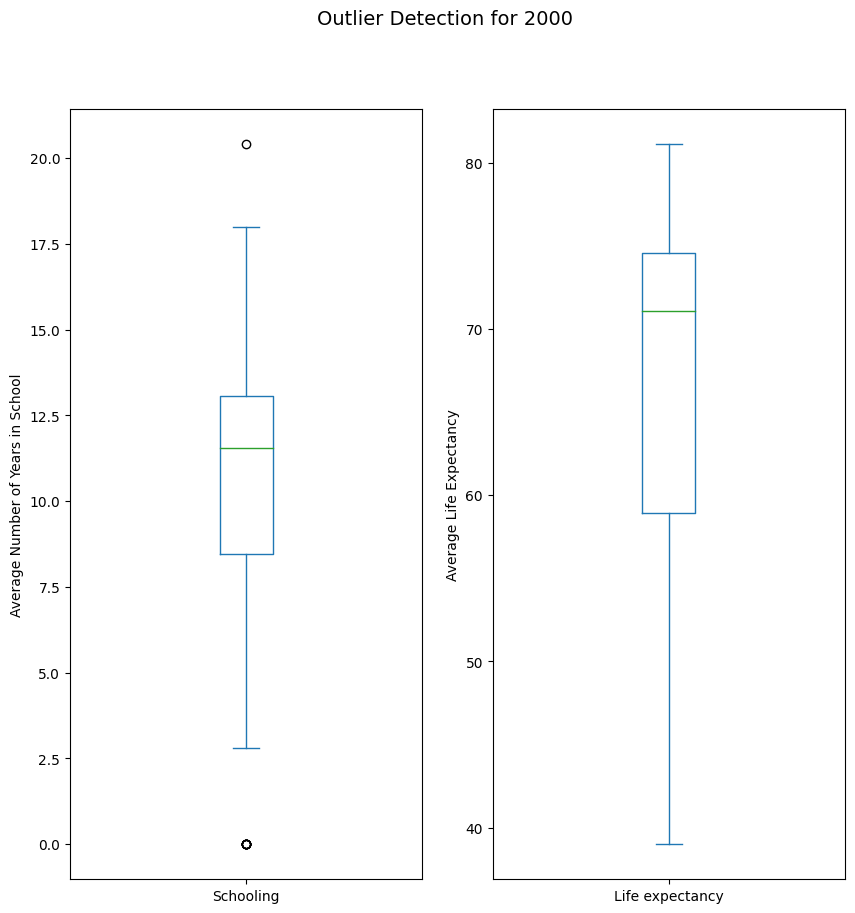

In [41]:
# 2000

fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Outlier Detection for 2000", fontsize=14)
schooling_2000_df['Schooling'].plot.box(ax=axis[0])
schooling_2000_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

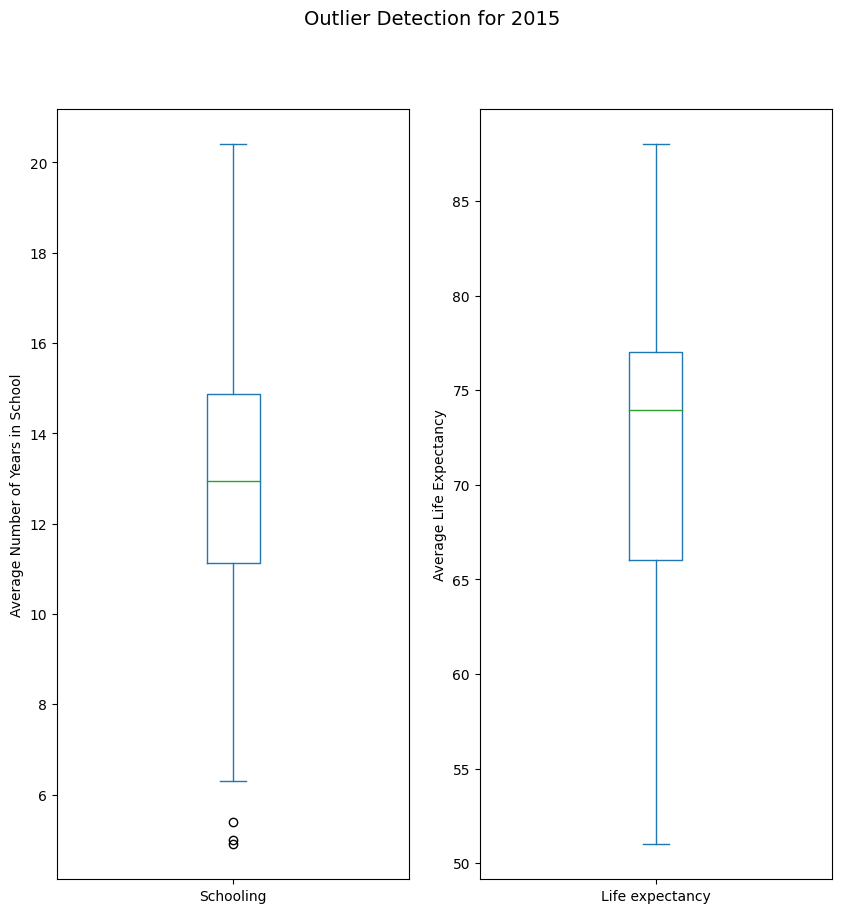

In [42]:
# 2015

fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Outlier Detection for 2015", fontsize=14)
schooling_2015_df['Schooling'].plot.box(ax=axis[0])
schooling_2015_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

In [43]:
# (2) Handeling outliers

In [44]:
# Handeling outliers for all years

schooling_df['Schooling'] = schooling_df['Schooling'].apply(lambda x: 5 if x <= 5 else x)
schooling_df['Schooling'] = schooling_df['Schooling'].apply(lambda x: 19 if x >= 19 else x)
schooling_df['Life expectancy'] = schooling_df['Life expectancy'].apply(lambda x: 46 if x <= 45 else x)

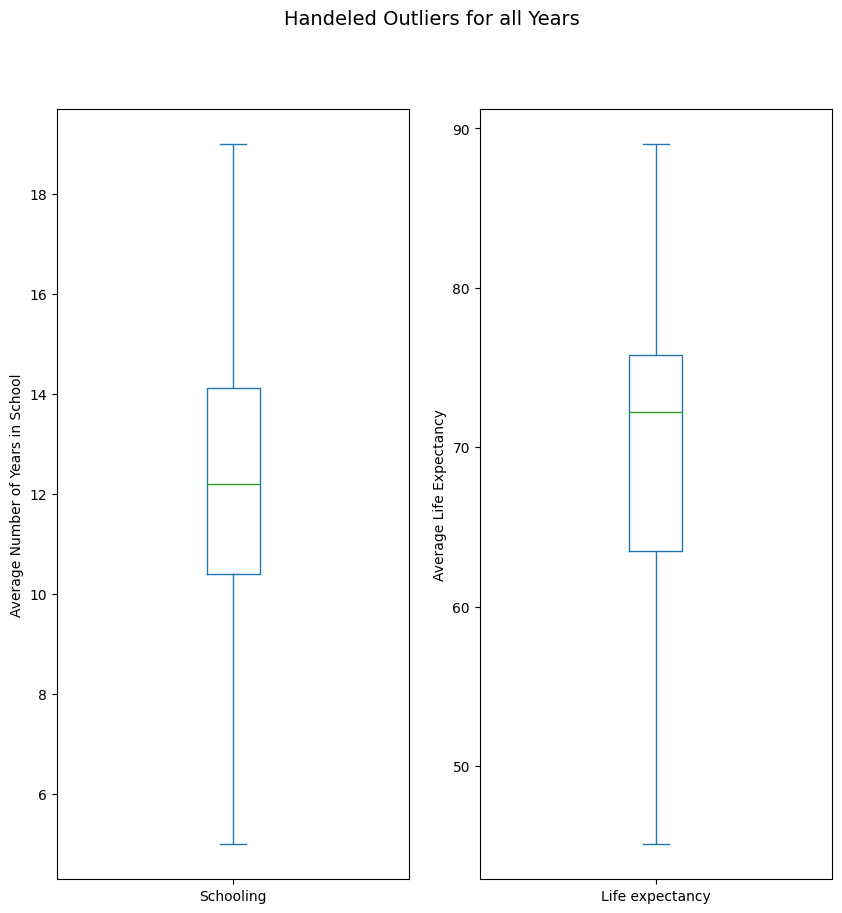

In [45]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Handeled Outliers for all Years", fontsize=14)
schooling_df['Schooling'].plot.box(ax=axis[0])
schooling_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

In [46]:
# Handeling outliers for 2000

schooling_2000_df['Schooling'] = schooling_2000_df['Schooling'].apply(lambda x: 2.4 if x <= 2.4 else x)
schooling_2000_df['Schooling'] = schooling_2000_df['Schooling'].apply(lambda x: 17.6 if x >= 17.6 else x)

C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_14972\3541467083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schooling_2000_df['Schooling'] = schooling_2000_df['Schooling'].apply(lambda x: 2.4 if x <= 2.4 else x)
C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_14972\3541467083.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schooling_2000_df['Schooling'] = schooling_2000_df['Schooling'].apply(lambda x: 17.6 if x >= 17.6 else x)


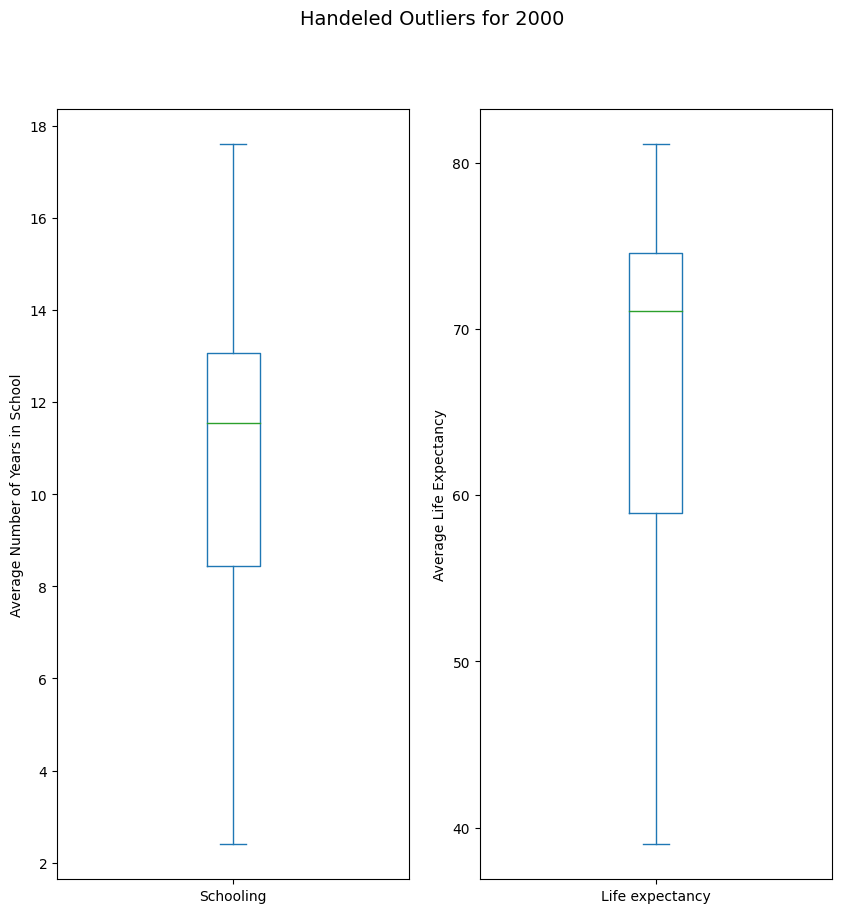

In [47]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Handeled Outliers for 2000", fontsize=14)
schooling_2000_df['Schooling'].plot.box(ax=axis[0])
schooling_2000_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

In [48]:
# Handeling outliers for 2015

schooling_2015_df['Schooling'] = schooling_2015_df['Schooling'].apply(lambda x: 6.2 if x <= 6.2 else x)

C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_14972\3924000954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schooling_2015_df['Schooling'] = schooling_2015_df['Schooling'].apply(lambda x: 6.2 if x <= 6.2 else x)


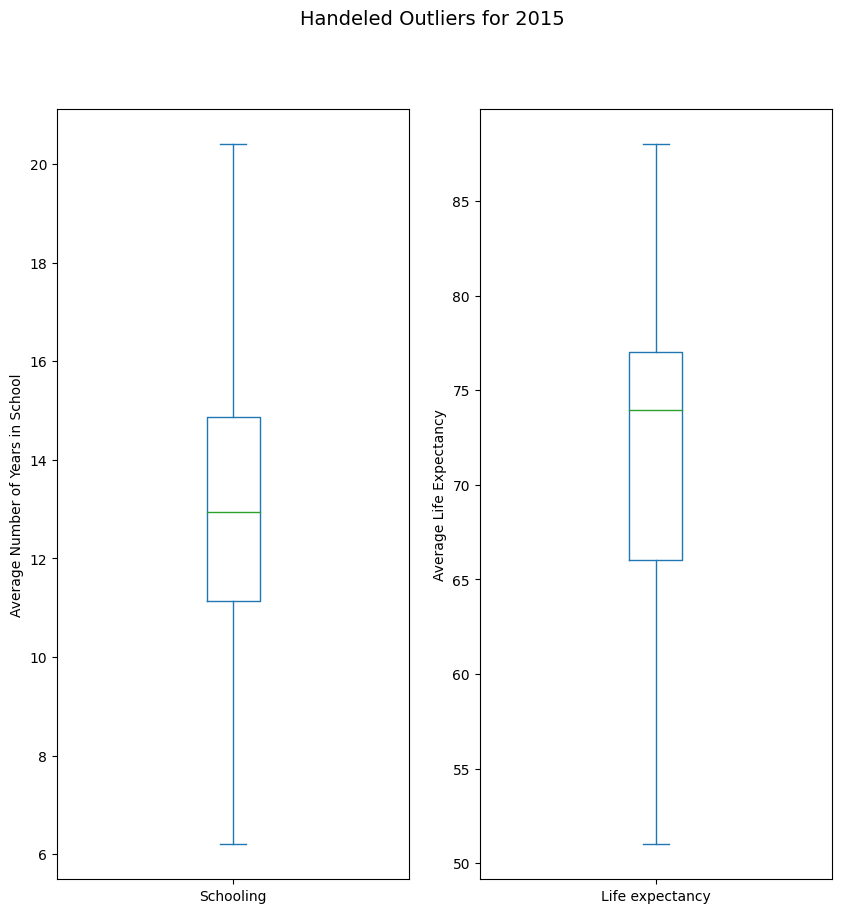

In [49]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
fig.suptitle("Handeled Outliers for 2015", fontsize=14)
schooling_2015_df['Schooling'].plot.box(ax=axis[0])
schooling_2015_df['Life expectancy'].plot.box(ax=axis[1])
axis[0].set_ylabel("Average Number of Years in School")
axis[1].set_ylabel("Average Life Expectancy")
plt.show()

In [50]:
schooling_df.sample(10)

,Country,Year,Schooling,Life expectancy
1352,Kuwait,2007,13.9,73.7
458,Cambodia,2005,10.0,62.9
1892,Panama,2011,12.9,77.3
2675,United Kingdom of Great Britain and Northern I...,2012,12.1,86.0
430,Côte d'Ivoire,2001,12.1,47.8
2261,Slovenia,2010,16.9,79.5
2844,Zimbabwe,2003,9.5,46.0
36,Algeria,2011,14.0,74.9
632,Cuba,2007,16.0,78.1
1571,Malta,2012,14.1,81.0


In [51]:
# (3) Explain handeling of outliers

**I chose to use boxplots to show the outliers in the data because boxplots show how the spread of data and it's very easy to see if there are any data points that are way larger or way smaller than the rest of the data.<br>
I chose to cap the highest and lowest values for all outliers to minimize the amount of data lost while still ensuring that the data follows a trend.**

### 4.3 Data quality and consistancy

In [52]:
# (1) Checking for data consistancy and accuracy

In [53]:
schooling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          2848 non-null   object 
 1   Year             2848 non-null   int64  
 2   Schooling        2848 non-null   float64
 3   Life expectancy  2848 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 89.1+ KB


In [54]:
# No negative values

print('Negative in Schooling:', (schooling_df['Schooling'] < 0).any())
print('Negative in Life expectancy:', (schooling_df['Life expectancy'] < 0).any())

Negative in Schooling: False
Negative in Life expectancy: False


In [55]:
# No duplicates

schooling_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2843    False
2844    False
2845    False
2846    False
2847    False
Length: 2848, dtype: bool

In [56]:
schooling_df[schooling_df.duplicated()]

,Country,Year,Schooling,Life expectancy


In [57]:
# (3) There were no transformations applied

**No transformations were performed, all data appeared to be consistent. There were no duplicated rows, Schooling and Life expectancy were floats. The Years were ints, which I felt was fine because it's just the year, not time or month/day.**

### 4.4 Data preparation for model training

In [58]:
# (1) Converting to a form a model can ingest

In [59]:
X = schooling_df[['Schooling']]
X_2015 = schooling_2015_df[['Schooling']]
X_2000 = schooling_2000_df[['Schooling']]

In [60]:
Y = schooling_df[['Life expectancy']]
Y_2015 = schooling_2015_df[['Life expectancy']]
Y_2000 = schooling_2000_df[['Life expectancy']]

In [61]:
# (2) Train, validation and test

In [62]:
# All years

X_train, X_validation_test, Y_train, Y_validation_test = train_test_split(X,Y, random_state=100, train_size=0.8, shuffle=True)
X_validation, X_test, Y_validation, Y_test = train_test_split(X_validation_test, Y_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [63]:
# 2015

X_2015_train, X_2015_validation_test, Y_2015_train, Y_2015_validation_test = train_test_split(X_2015,Y_2015, random_state=100, train_size=0.8, shuffle=True)
X_2015_validation, X_2015_test, Y_2015_validation, Y_2015_test = train_test_split(X_2015_validation_test, Y_2015_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [64]:
# 2000

X_2000_train, X_2000_validation_test, Y_2000_train, Y_2000_validation_test = train_test_split(X_2000,Y_2000, random_state=100, train_size=0.8, shuffle=True)
X_2000_validation, X_2000_test, Y_2000_validation, Y_2000_test = train_test_split(X_2000_validation_test, Y_2000_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [168]:
# (3) Label encoding not needed

In [169]:
# (4) Normalize not needed

In [170]:
# (5) Explain the transformations

**No transformations were applied, all data looked consistant. I split the data into train(80%), validation(10%) and test(10%) and I plan on using Linear regresssion to train the model to show the relationship between Schooling and Life expectancy.**

## Problem 5: Data Visulaization

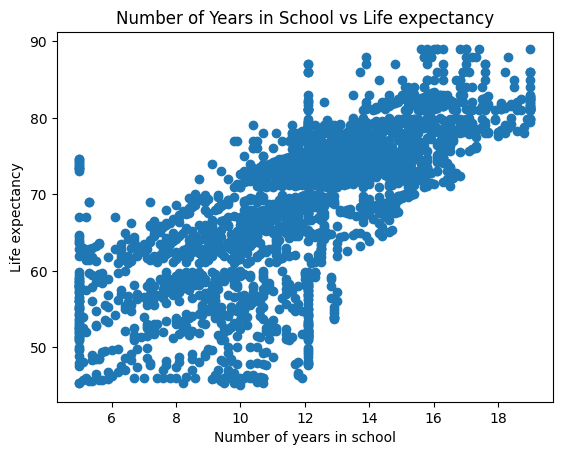

In [190]:
# Scatter plot of how schooling affects life expectancy

plt.scatter(x=schooling_df['Schooling'].values, y=schooling_df['Life expectancy'].values)
plt.title('Number of Years in School vs Life expectancy')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

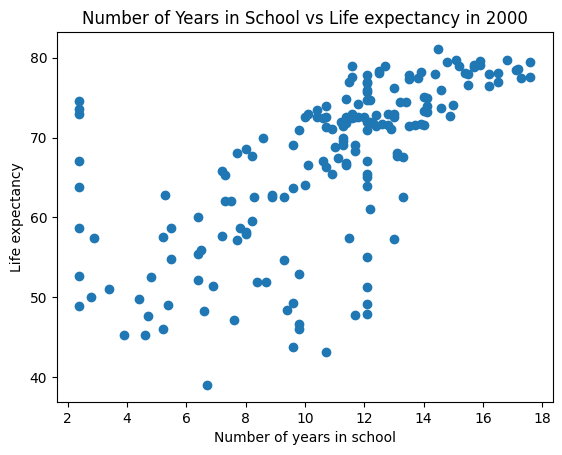

In [194]:
plt.scatter(x=schooling_2000_df['Schooling'].values, y=schooling_2000_df['Life expectancy'].values)
plt.title('Number of Years in School vs Life expectancy in 2000')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

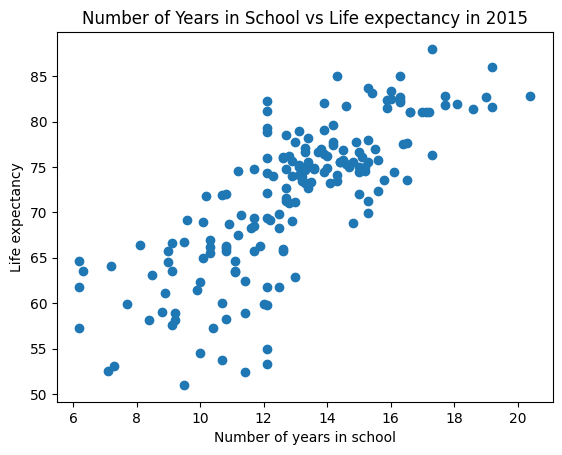

In [199]:
plt.scatter(x=schooling_2015_df['Schooling'].values, y=schooling_2015_df['Life expectancy'].values)
plt.title('Number of Years in School vs Life expectancy in 2015')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

In [177]:
# Average schooling thorugh the years

avg_schooling_per_year = []
years = []

year = 2000
for i in range (0, 16):
    years.append(year)
    avg_school = schooling_df[schooling_df['Year'] == year]['Schooling'].mean()
    year += 1
    avg_schooling_per_year.append(avg_school)

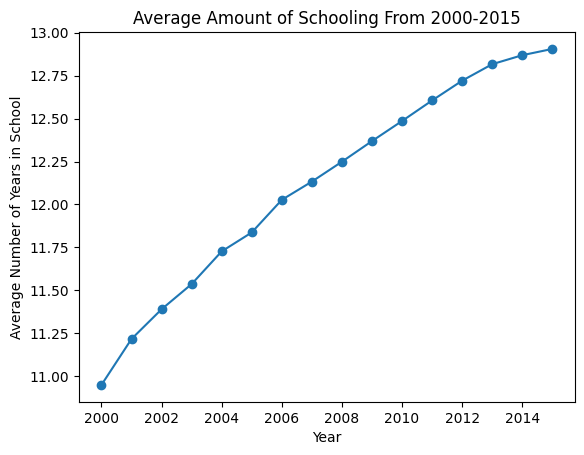

In [178]:
# Line graph of average amount of schooling through the years

plt.plot(years, avg_schooling_per_year, marker = 'o')
plt.title('Average Amount of Schooling From 2000-2015')
plt.xlabel('Year')
plt.ylabel('Average Number of Years in School')
plt.show()

In [179]:
# Average life expectancy through the years

avg_life_per_year = []
years = []

year = 2000
for i in range (0, 16):
    years.append(year)
    avg_life = schooling_df[schooling_df['Year'] == year]['Life expectancy'].mean()
    year += 1
    avg_life_per_year.append(avg_life)

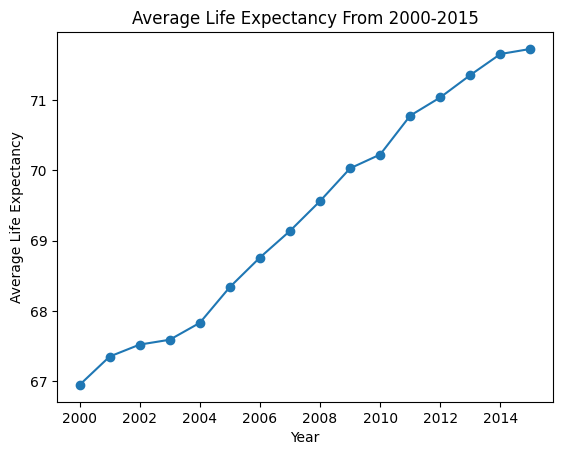

In [180]:
# Line graph of average life expectancy through the years

plt.plot(years, avg_life_per_year, marker='o')
plt.title('Average Life Expectancy From 2000-2015')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.show()

In [488]:
# Five random countries to look at for life expectancy through the years

five_countries = schooling_2000_df.sample(5)
five_countries

,Country,Year,Schooling,Life expectancy
2351,Spain,2000,15.7,79.1
943,Georgia,2000,11.4,71.8
2255,Slovakia,2000,13.0,73.0
1087,Haiti,2000,7.8,58.6
1535,Malaysia,2000,11.6,72.4


In [489]:
years = [2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015]
countries = five_countries['Country'].unique()
country_life_expect = [[]]

for country in countries:
    country_life_per_year = []
    year = 2000 
    for i in range (0,16):
        life_per_year = schooling_df[(schooling_df['Year'] == year) & (schooling_df['Country'] == country)]['Life expectancy'].mean()
        country_life_per_year.append(life_per_year)
        year += 1
    country_life_expect.append(country_life_per_year)
    
del country_life_expect[0]


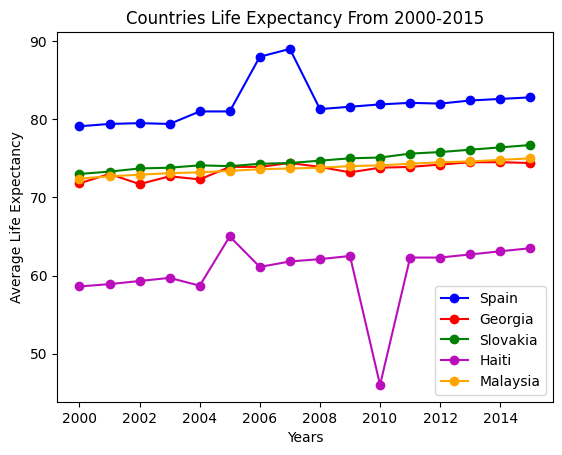

In [490]:
# Line graph of some countries' life expectancies

plt.plot(years, country_life_expect[0], label=countries[0], color='blue', linestyle='-', marker='o')
plt.plot(years, country_life_expect[1], label=countries[1], color='red', linestyle='-', marker='o')
plt.plot(years, country_life_expect[2], label=countries[2], color='green', linestyle='-', marker='o')
plt.plot(years, country_life_expect[3], label=countries[3], color='#ba0ebd', linestyle='-', marker='o')
plt.plot(years, country_life_expect[4], label=countries[4], color='orange', linestyle='-', marker='o')
plt.title('Countries Life Expectancy From 2000-2015')
plt.xlabel('Years')
plt.ylabel('Average Life Expectancy')
plt.legend()
plt.show()

**I chose to show a scatter plot of the number of years spent studying in school vs the average life expectancy to show how schooling affected life expectancy. I felt like a scatter plot was a good choice because each country would be represented as a dot and you could kind of tell how many countries had a certain number of years spent in school and how that affected the life expectancy. I also plotted scatter plots of just the 2000 and just the 2015 correlation between the number of years spent studing in school and life expectancy because I thought it would be interesting to see how the two compared.<br>
I also plotted line graphs of how the average number of years spent in school changed over time and how the average life expectancy changed over time. I also plotted the life expectancy over time for some random countries to see how they would compare.<br>
From these graphs we can see that life expectancy goes up throughout the years and so does the amount of schooling. The scatter plots show how more schooling means higher life expectancy, which makes sense based on the line graphs. An interesting thing I saw was while I was plotting the life expectancies of different countries through the years is that Hati's life expectancy took a really big hit in 2010 and that was likely due to the earthquake that year. You can also see from the scatter plots that the average life expectancy was higher in 2015 than it was in 2000 because the Y-axis went up to 85 for the 2015 scatter plot and only went to 80 for the 2000 scatter plot. There was also more correlation between life expectancy and schooling for 2015 than three was for 2000.**

## Problem 6: Evaluation Metrics

### 1)

For the Linear Regression model I plan on using mean squared error. Mean Squared Error is the average squared differences between actual values and predicted values to find how well a regression model works. So it basically measures the accuracy of the prediction of the model by taking the distances between actual and predicted points and squaring them.

The lower the MSE value, the closer the model is to the actual. 
The formula for Mean Squared error can be given as:
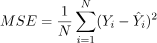
Where it shows the sum of the distance between the actual points and a predicted points. Which is then divided by the number of total observations, getting the mean.

Pros:
- Easy to calculate
- Simple to understand
- Larger errors are very obvious (so you can deal with them accordingly)

Cons:
- Error not given in terms of target
- Can be difficult to interpret

### 2)

For the Gneralized Linear Model I plan to look at the deviance to evaluate the fit of the model compared to a saturated model. It measures the difference between the log-likelihood of the estimated model and the saturated model to get a number that can be used to tell how well the model works for the data. 

Lower deviance indicates a better fit and the formula for deviance is given as:
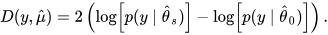
Where the difference between the fitted values of the saturated model and fitted values of the parameters of the model are taken as a log function and the maximum value of likelihood for a model are taken in the log as well.

Pros:
- Can be used to compare different models
- Reliable for large sample sizes

Cons:
- Heavily influenced by outliers
- Does not account for model complexity
- Gives good overall measure but does not give good information about specific patterns and issues in the model

## Problem 7: Model Training (One of Two)

### 7.1 Picking a model

In [181]:
# (1) Pick a machine learning algorithm

The machine learning model that I choose to use is Linear regression

In [182]:
# (2) Paragraph explaining the model

Linear regression is a model that makes predictions for continuous variables. It shows the relationship between independent and dependent variables which makes sense for the problem that I am looking at with my dataset. I want to show what happens as the average number of years spent studying in school increases and decreases and how it affects life expectancy and a linear regression model is used to learn and predict the values of certain variables. This means that it can find the trend of the data and show it through the line of best fit.

### 7.2 Model training

In [183]:
# (1) Training and reporting on validation dataset

In [184]:
regr = LinearRegression()
regr.fit(X_train, Y_train)
Y_pred = regr.predict(X_validation)

print('Linear regression:',mean_squared_error(Y_validation, Y_pred))

Linear regression: 42.30685519077787


In [185]:
lasso = Lasso()
lasso.fit(X_train, Y_train)
Y_pred = lasso.predict(X_validation)

print('Lasso:',mean_squared_error(Y_validation, Y_pred))

Lasso: 42.61691428756407


In [186]:
ridge = Ridge()
ridge.fit(X_train, Y_train)
Y_pred = ridge.predict(X_validation)

print('Ridge:',mean_squared_error(Y_validation, Y_pred))

Ridge: 42.30707307223887


In [187]:
# (2) Appropriate tasks for Linear Regression: Estimate the model (graph line of best fit)

In [188]:
# (3) Hyperparameters, for Linear Regression: intercept and slope of regression

In [189]:
# line of best fit

b = regr.intercept_
w1 = regr.coef_[0]
print('All years:',w1,'x +', b, 'b')

All years: [2.2989839] x + [41.51838465] b


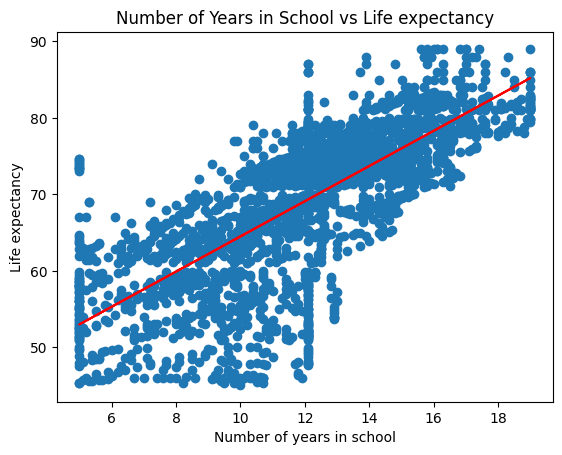

In [191]:
plt.scatter(x=schooling_df['Schooling'].values, y=schooling_df['Life expectancy'].values)
plt.plot(schooling_df['Schooling'].values, (w1*schooling_df['Schooling'])+b, 'r')
plt.title('Number of Years in School vs Life expectancy')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

In [192]:
regr = LinearRegression()
regr.fit(X_2000_train, Y_2000_train)
Y_2000_pred = regr.predict(X_2000_validation)

print('Linear regression in 2000:',mean_squared_error(Y_2000_validation, Y_2000_pred))

Linear regression in 2000: 52.05603182147928


In [193]:
# line of best fit

b_2000 = regr.intercept_
w1_2000 = regr.coef_[0]
print('2000:',w1_2000,'x +', b_2000, 'b')

2000: [1.75748839] x + [48.09058555] b


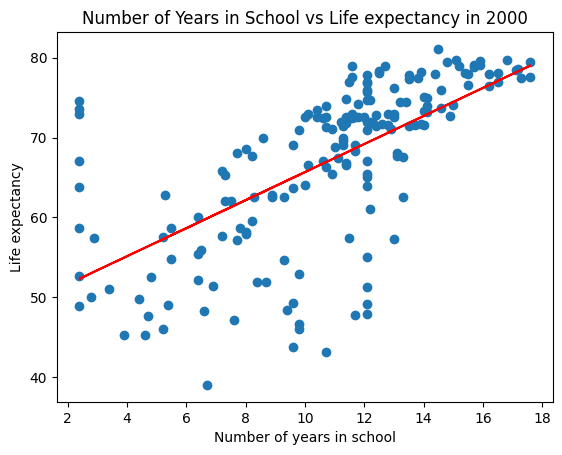

In [195]:
plt.scatter(x=schooling_2000_df['Schooling'].values, y=schooling_2000_df['Life expectancy'].values)
plt.plot(schooling_2000_df['Schooling'].values, (w1_2000*schooling_2000_df['Schooling'])+b_2000, 'r')
plt.title('Number of Years in School vs Life expectancy in 2000')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

In [196]:
regr = LinearRegression()
regr.fit(X_2015_train, Y_2015_train)
Y_2015_pred = regr.predict(X_2015_validation)

print('Linear regression in 2015:',mean_squared_error(Y_2015_validation, Y_2015_pred))

Linear regression in 2015: 37.92039435188911


In [197]:
# line of best fit

b_2015 = regr.intercept_
w1_2015 = regr.coef_[0]
print('2015:',w1_2015,'x +', b_2015, 'b')

2015: [2.18984773] x + [43.59364674] b


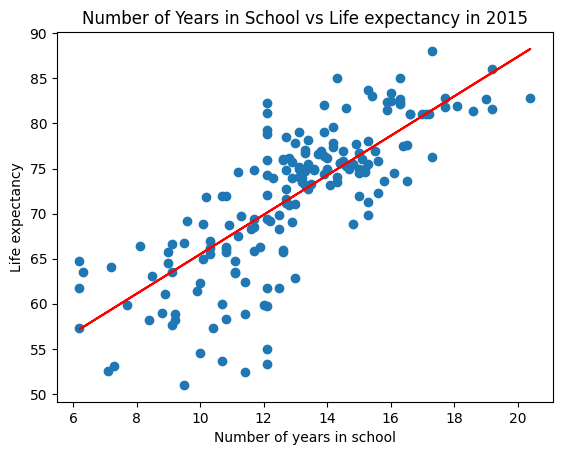

In [200]:
plt.scatter(x=schooling_2015_df['Schooling'].values, y=schooling_2015_df['Life expectancy'].values)
plt.plot(schooling_2015_df['Schooling'].values, (w1_2015*schooling_2015_df['Schooling'])+b_2015, 'r')
plt.title('Number of Years in School vs Life expectancy in 2015')
plt.xlabel('Number of years in school')
plt.ylabel('Life expectancy')
plt.show()

**I choose to train the model using Linear regression to show the trend between schooling and life expectancy for all years, 2000 and 2015. I then plotted the line of best fit that I got for the years on the scatter plots to show the correlation. It looks like Linear Regression worked quite well, the trend lines look like they fit well and the trend is clear.**

#### **Considering using Lasso as second model to train

In [201]:
lasso = Lasso()
lasso.fit(X_train, Y_train)
Y_pred = lasso.predict(X_validation)

print('Lasso:',mean_squared_error(Y_validation, Y_pred))

Lasso: 42.61691428756407


In [202]:
# The line of best fit is different but is not noticable on the scatter plot

b_lasso = lasso.intercept_
w1_lasso = lasso.coef_[0]
print('lasso:',w1_lasso,'x +', b_lasso, 'b')

lasso: 2.191736385677208 x + [42.81481789] b


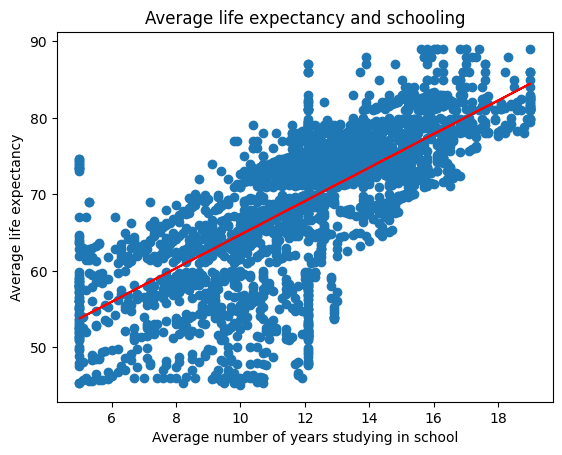

In [203]:
plt.scatter(x=schooling_df['Schooling'].values, y=schooling_df['Life expectancy'].values)
plt.plot(schooling_df['Schooling'].values, (w1_lasso*schooling_df['Schooling'])+b_lasso, 'r')
plt.title('Average life expectancy and schooling')
plt.xlabel('Average number of years studying in school')
plt.ylabel('Average life expectancy')
plt.show()

#### **The difference between Lasso and Linear Regression was very small so I decided not to compare the two models and chose a differnt model for Problem 8

## Problem 8: Model Training (Two of Two)

### 8.1 Picking another model

In [204]:
# (1) Picking another model

The second machine learning model that I chose to use is Generalized Linear Model (GLM) 

In [205]:
# (2) Paragraph explaining the model

GLM is a regression model that is a flexible generalization of regular linear regression. GLM can be used with data that does not have normal distribution. GLM allows for a relationship between the response and predictors to be built by using a link function. That way the relationship does not need to be linear, making it more flexible than regular linear regression models.The errors are said to follow an exponental distribution and are not necessarily normally distrubuted. GLM is best used for linear relationships and the variance of errors are not constant and vary with X. 

### 8.2 Model training

In [206]:
# For all years

X_glm = schooling_df['Schooling']
Y_glm = schooling_df['Life expectancy']

In [207]:
X_glm = sm.add_constant(X_glm)

In [208]:
glm_model = sm.GLM(Y_glm, X_glm, family=sm.families.Gaussian())  
result = glm_model.fit()

In [209]:
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Life expectancy   No. Observations:                 2848
Model:                            GLM   Df Residuals:                     2846
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          40.739
Method:                          IRLS   Log-Likelihood:                -9319.2
Date:                Sat, 05 Aug 2023   Deviance:                   1.1594e+05
Time:                        09:33:57   Pearson chi2:                 1.16e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.3750      0.493     83.969      0.0

In [210]:
# Deviance for all years

print('Deviance for all years:',result.deviance)

Deviance for all years: 115943.53505781341


In [211]:
# For 2015

X_glm_2015 = schooling_2015_df['Schooling']
Y_glm_2015 = schooling_2015_df['Life expectancy']

In [212]:
X_glm_2015 = sm.add_constant(X_glm_2015)

In [213]:
glm_model_2015 = sm.GLM(Y_glm_2015, X_glm_2015, family=sm.families.Gaussian())  
result_2015 = glm_model_2015.fit()

In [214]:
print(result_2015.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Life expectancy   No. Observations:                  178
Model:                            GLM   Df Residuals:                      176
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          25.909
Method:                          IRLS   Log-Likelihood:                -541.22
Date:                Sat, 05 Aug 2023   Deviance:                       4560.0
Time:                        09:34:01   Pearson chi2:                 4.56e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7880
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.2121      1.817     23.232      0.0

In [215]:
# Deviance for 2015

print('Deviance for 2015:',result_2015.deviance)

Deviance for 2015: 4559.969451546552


In [216]:
# For 2000

X_glm_2000 = schooling_2000_df['Schooling']
Y_glm_2000 = schooling_2000_df['Life expectancy']

In [217]:
X_glm_2000 = sm.add_constant(X_glm_2000)

In [218]:
glm_model_2000 = sm.GLM(Y_glm_2000, X_glm_2000, family=sm.families.Gaussian())  
result_2000 = glm_model_2000.fit()

In [219]:
print(result_2000.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Life expectancy   No. Observations:                  178
Model:                            GLM   Df Residuals:                      176
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          60.282
Method:                          IRLS   Log-Likelihood:                -616.38
Date:                Sat, 05 Aug 2023   Deviance:                       10610.
Time:                        09:34:04   Pearson chi2:                 1.06e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.5368
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.7851      1.813     25.806      0.0

In [220]:
# Deviance for 2000

print('Deviance for 2000:',result_2000.deviance)

Deviance for 2000: 10609.70237958473


In [221]:
# Hyperparameters: link function for Gaussian

print(sm.families.links.Identity())

**After using the GLM to show the fit of the model on the data I found that the variance for all three datasets (all years, 2015 and 2000) were very high (all years being the highest and 2015 being the lowest) which meant that the relationship between the variables was low.**

## Problem 9: Report Results

In [222]:
# (1) Which is the better model?

Linear Regression was the better model. 

For the project I trained a Linear Regression model and Generalized Linear Model to see the correlation between the amount of years studing in school and the life expectancy of a country. The Linear Regression model seemed to be the better model for what I was looking to see in this project and it also seemed to be the better fitting model as well. In the Linear Regression model I looked at the line of best fit to see the correlation between shcooling and life expectancy and looked at how well the line fitted the data by using a scatter plot. The lines showed a clear correlation for all three datasets (one for all years, one for 2000 and one for 2015) where an increase in the number of years spent studying in school meant greater life expectancy. For the Generalized Linear Model I looked at the deviance score to see how well schooling and life expectancy correlated with each other. The correlation between the two could be estimated by looking at the deviance. I trained GLM on the three dtatasets  and found that all three had very high deviance values which meant that the relationship between schooling and life expectancy was not very high. Linear Regression was better suited for what I was looking at and I preferred the visualization of the trend line for schooling vs. life expectancy to see the correlation rather than the deviance values. The question that I wanted to answer for this project was also how schooling would affect the life expectancies of different countries and Linear Regression was able to show what that relationship was while GLM could only give a value of how well schooling correlated with life expectancy and not the actual relationship. GLM also showed that there was poor correlation between schooling and life expectancy while Linear Regression showed that the two had a pretty strong positive correlation. For these reasons I think Linear Regression was the better model for my project.

In [223]:
# (2) Summarize project

In this project I looked at the Country's Life Expectancy dataset which included different countries and their life expectancies. The dataset includes data of different countries from 2000-2015 for each country. It included factors that could affect life expectancy like vaccination percentages for certain diseases (Hepatitis B, Polio, Diphtheria), the number of infant and under five years deaths, the number of people who got certain diseases(Measles, HIV/AIDS), total expenditure, GDP, BMI and schooling.<br>
For this project I wanted to look at the trend of how different amounts of schooling can affect a country's life expectancy. To do this I looked at the schooling, life expectancy and years. I wanted to see the trend between schooling and life expectancy for all years, just 2000 and just 2015. While exploring the dataset I noticed that life expectancy generally increased throughout the years and so did the average number of years spent studying in school. I also saw that as the amount of schooling went up, the life expectancy generally also increased.<br>
I decided that a regression model would be the best fit to show the trend between schooling and life expectancy so I looked at three models for regression, Linear Regression, Lasso and Ridge. I split each group of data into train(80%), validation(10%) and test(10%). Then I trained each of the three models on the data from all years and found that Linear Regression worked the best on validation by using Mean Squared Error as the metric. So I used Linear Regression to find the line of best fit for the scatter plot of average schooling of countries from all years, just 2000 and just 2015. The lines fit the trend for all of the different data and I was able to see a clear correlation between the number of years spent studying in school and the average life expectancy.<br>
For the second model I considered looking at Lasso and Ridge, which were very similar to Linear Regression, to compare how the differed from Linear Regression. But eventhough there were slight differences in the Mean Squared Error values and the euqations for the line of best fit, the visulaization of the lines were too similar to give any meaningful comparisions.<br>
So for the second model I decided to use the Generalized Linear Model to calculate how well schooling correlated with life expectancy instead. I chose to look at the Gaussian distribution since that was used for continuous variables and then I looked at the deviance values of the data for all years, 2000 and 2015 and saw that they were all very high, which meant that there was not a strong correlation between schooling and life expectancy.<br>
In conclusion, I found that the Linear Regression model was better suited to find the correlation between schooling and life expectancy. I found that, generally, as a country's average number of years spent studing in school increases, so does their life expectancy. This was shown through the scatter plots and the line of best fit from the Linear Regression model. 

## Problem 12: Ethics Question

#### WEEK 2 : AI IN POLITICAL CONTENT

**How might the rapid increase in numbers of deepfakes during an election impact the democratic process and the public’s ability to make informed decisions?**

I think the rapid increase of deepfakes during an election might impact the democratic process and the public’s ability to make informed decisions by causing a lot of distrust among different parties and increasing the bipartisanship in the country. More deepfakes means that there will be more misinformation that will be spread during the election season and many people might get confused by these deepfakes and spread the misinformation which might impact the election in a negative way. Many people also might not know about deepfakes, this is the first time I am hearing of them, and this can affect how people perceive the different parties. Deepfakes and AI generated photos can make it harder for people to differentiate between real and fake and it can affect the outcome of elections in a way that is not honest. Honestly, I’m kind of surprised that technology has even come to the point where deepfakes can look so realistic and I’m worried that this will lead to a lot of distrust between the parties because of how difficult it is to differentiate a deepfake from the real thing. The example video that was shown in the article was very believable and I had a hard time telling that it was fake. If there are many types of fake videos of politicians saying or doing things that they have never said or done before it can impact them in a way that is untruthful, whether positively or negatively. I think this ethics question is very interesting because it is intentionally putting misleading information out into the public media and can cause a rift in the political and democratic system of the United States. I also don’t know how these deepfakes can be stopped because once someone posts one, other people can take it and repost it and they can spread very rapidly. I guess it’s important for the public to be mindful of what they see online and always fact check the information that they are getting to hopefully avoid getting tricked by the deepfakes online. 


**Do you think social media platforms have a responsibility in combating the spread of deepfakes and ensuring the integrity of political discourse? Why/Why not?**

Yes I do think that social media platforms have a responsibility in combating the spread of deepfakes and misinformation because of how large their user base is and how fast that information can travel in a short amount of time. Social media platforms should have a responsibility to make sure that the information that they are putting out is accurate to ensure that their users aren’t being intentionally misled. People will likely see deepfakes, assume they are real and repost and spread the fake news or video and inorder to stop or lessen the spread of the misinformation social media platforms should make an effort to fact check their posts and limit the exposure of the deepfakes. There’s obviously no way to track down and stop all deepfakes, but social media platforms and news outlets just being mindful of the information that they are putting out can greatly affect the amount of deepfakes being spread and that can mean more integrity for the political system. Since social media is such an integrated part of our lives and they affect every decision that we make, they should try to be a reliable source of information to the general public so we can make informed decisions. In recent years there has been an increase in deepfakes and other AI generated images that can be used to push a political agenda and affect how people trust the different parties and each other. Companies, and people, should be trying to prevent the spread of the misleading information that might be put out and I think the use of deepfakes is going to be a much larger problem in the future. There might not be a way to completely eliminate the use of deepfakes, but there are things we can do to lessen the impact on our society. 